In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings('ignore')

/kaggle/input/datasets/faizanhaider01/glass-ds/glass.csv


In [5]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/glass-ds/glass.csv')

In [6]:
df.sample(5)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
98,1.51689,12.67,2.88,1.71,73.21,0.73,8.54,0.00,0.00,2
195,1.51545,14.14,0.00,2.68,73.39,0.08,9.07,0.61,0.05,7
64,1.52172,13.48,3.74,0.90,72.01,0.18,9.61,0.00,0.07,1
122,1.51687,13.23,3.54,1.48,72.84,0.56,8.10,0.00,0.00,2
192,1.51623,14.20,0.00,2.79,73.46,0.04,9.04,0.40,0.09,7


In [7]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [8]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [9]:
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import seaborn as sns
from sklearn.metrics import r2_score

In [10]:
X = df.drop(columns=['Type'])
y = df.iloc[:,-1]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
# Applying Regression without any transformation
lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.7956189295308949

In [13]:
# Cross checking with cross val score
lr = LogisticRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.5880434740732347)

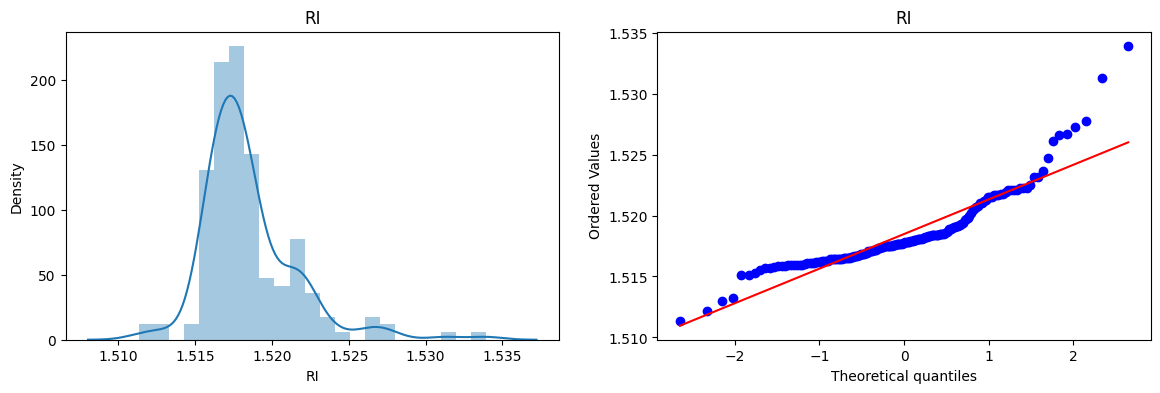

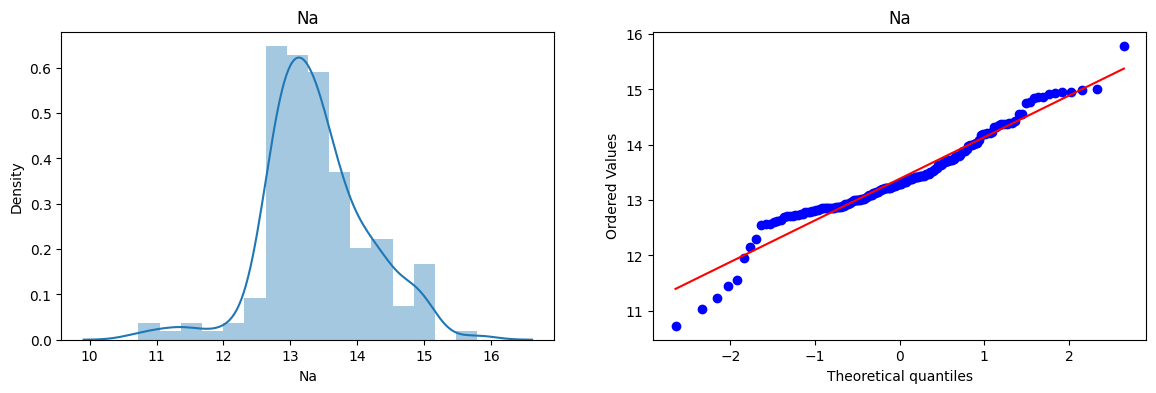

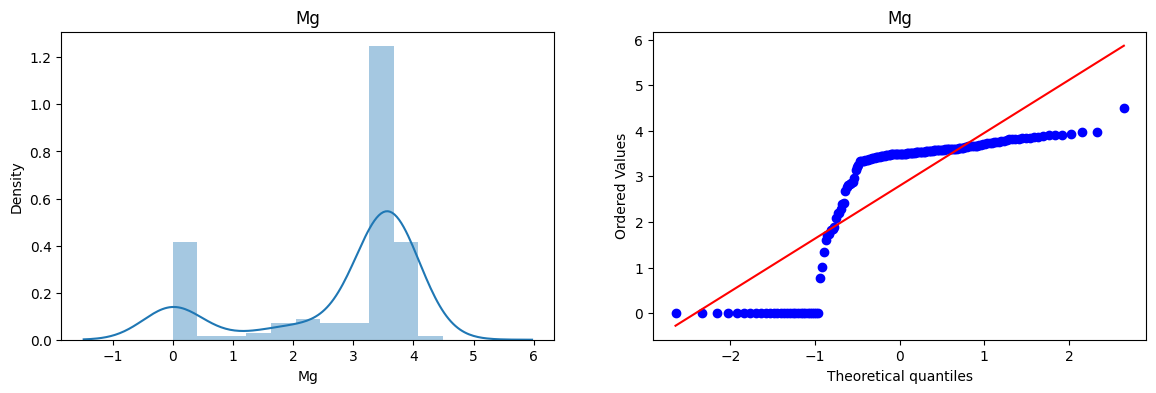

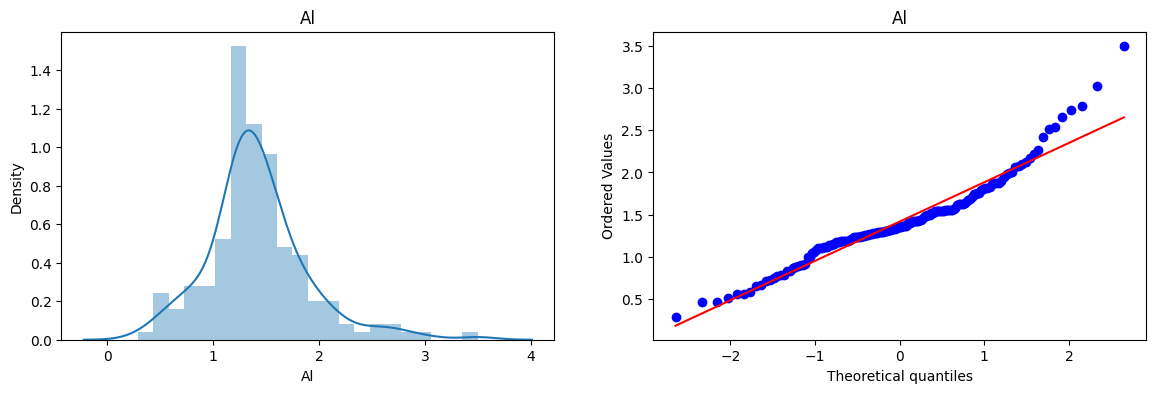

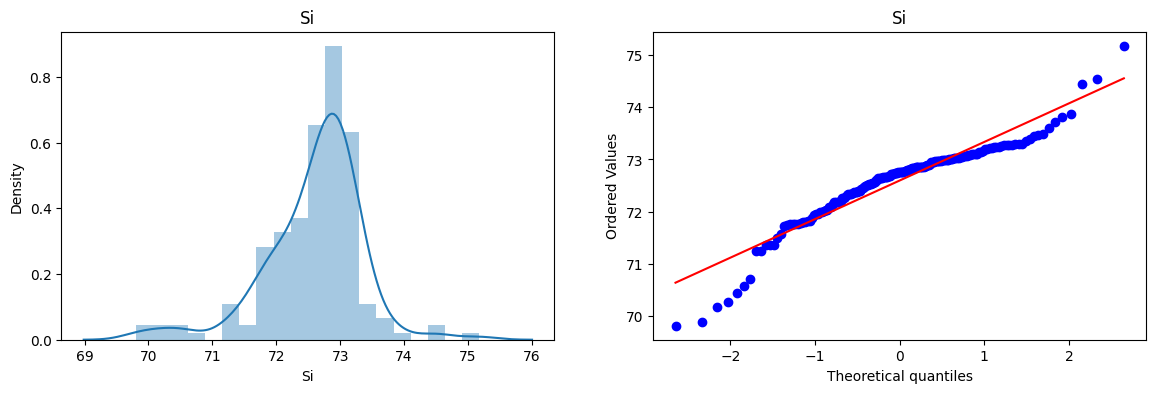

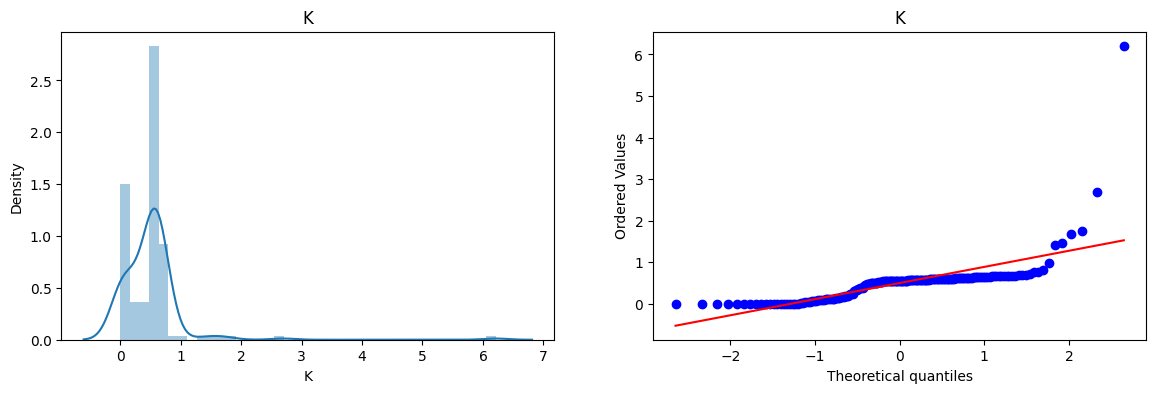

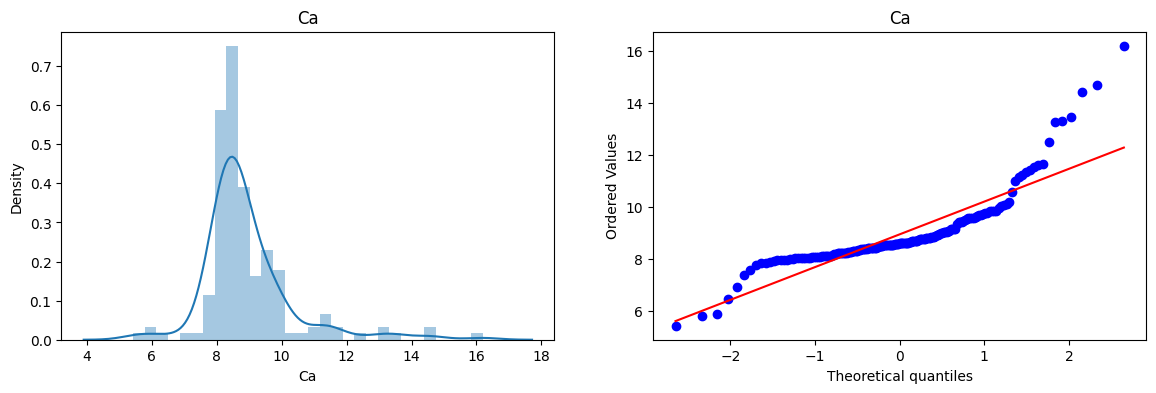

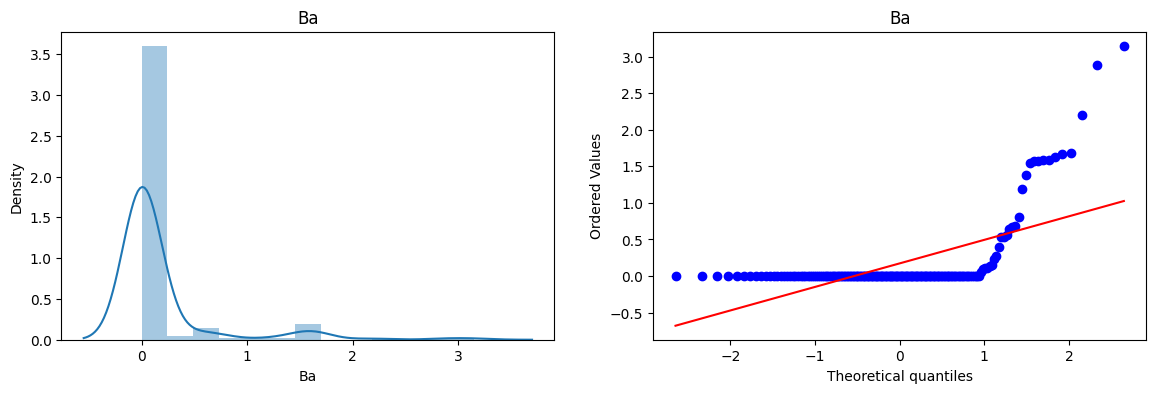

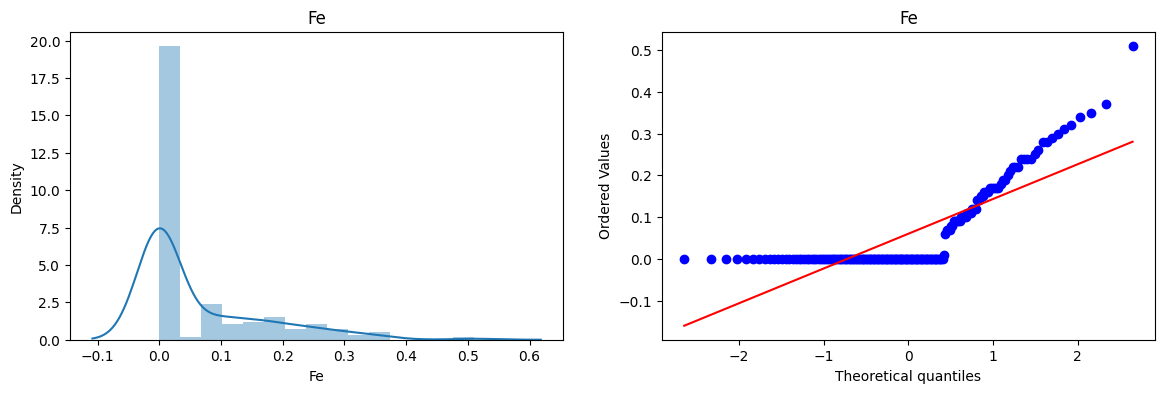

In [14]:

# Plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
ss = StandardScaler()
X_train_transformed = ss.fit_transform(X_train)

In [17]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,RI,-180.153205
1,Na,1.165307
2,Mg,0.369213
3,Al,0.487506
4,Si,16.165998
5,K,0.352124
6,Ca,-0.993262
7,Ba,-0.432734
8,Fe,-0.172989


In [18]:
# Applying linear regression on transformed data

lr = LogisticRegression()
lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)

r2_score(y_test,y_pred2)

0.7867327960322381

In [19]:

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LogisticRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.49639516514594284)

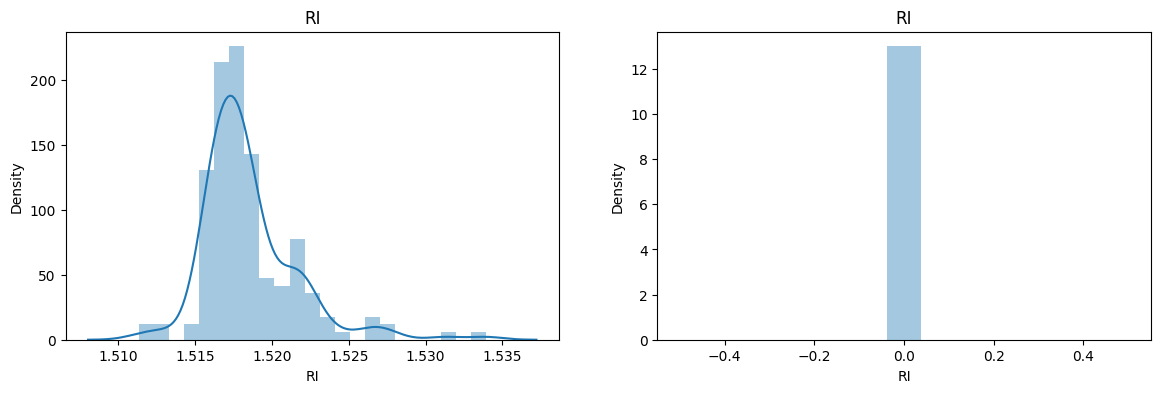

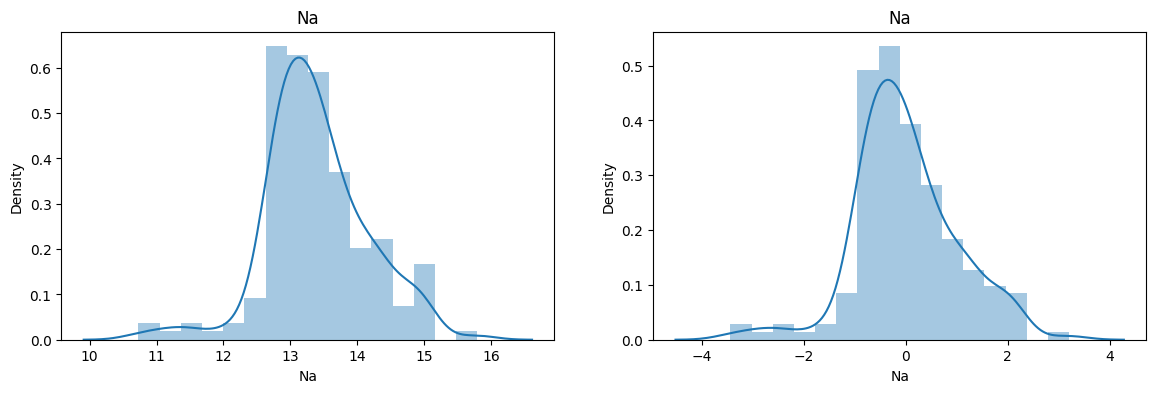

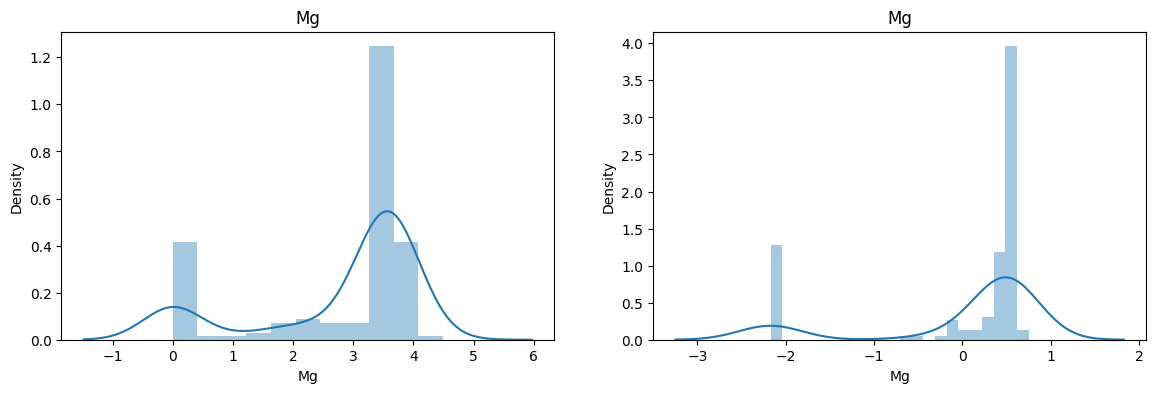

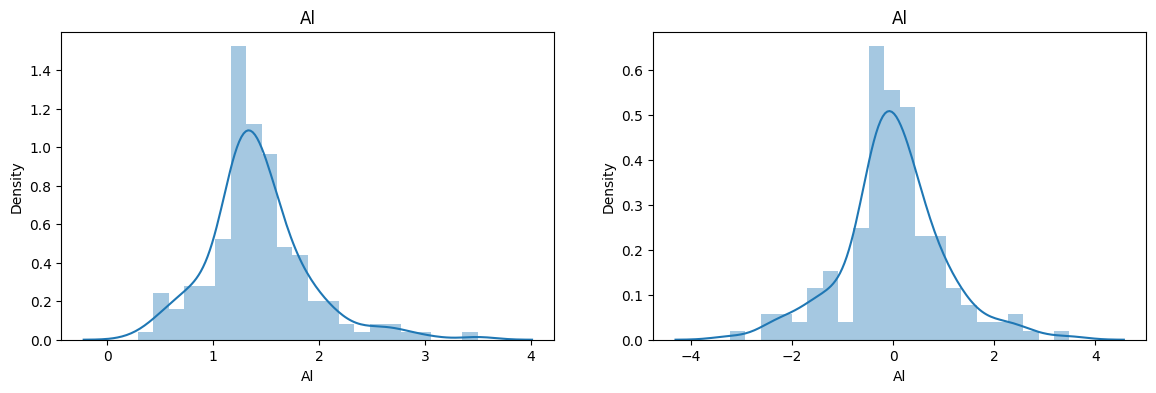

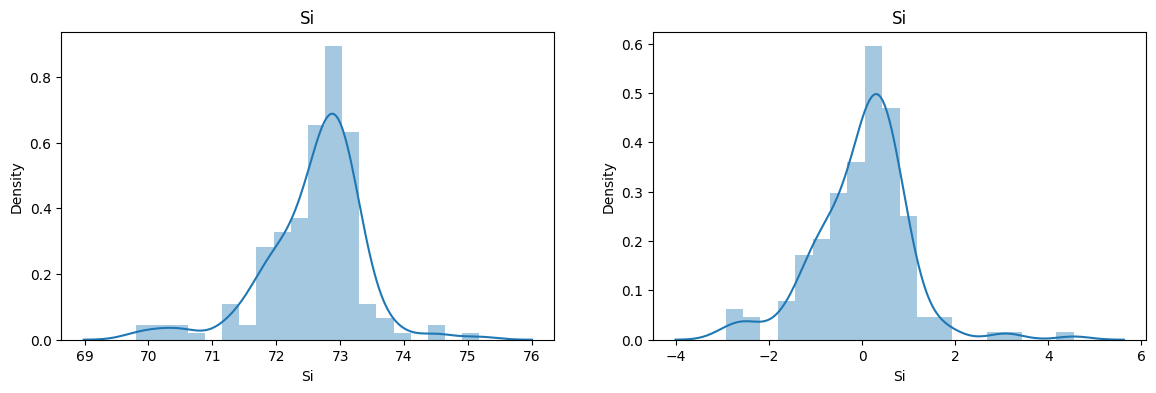

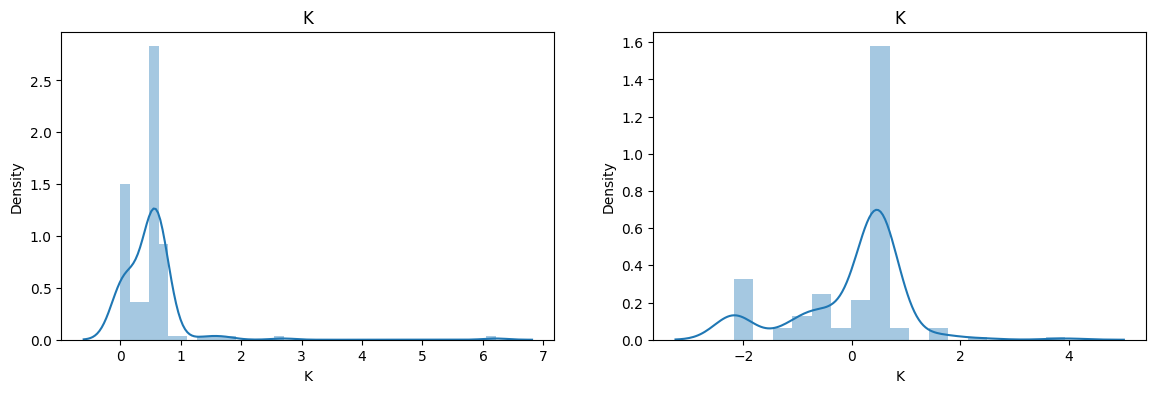

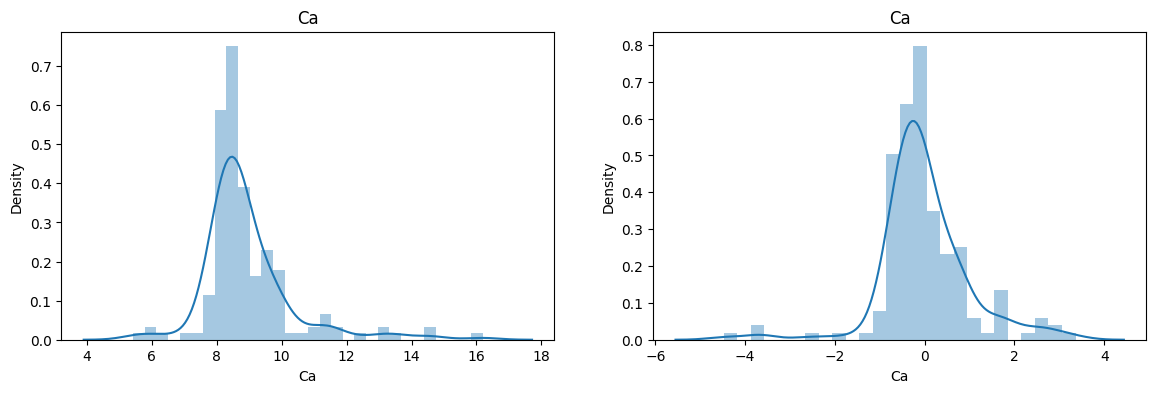

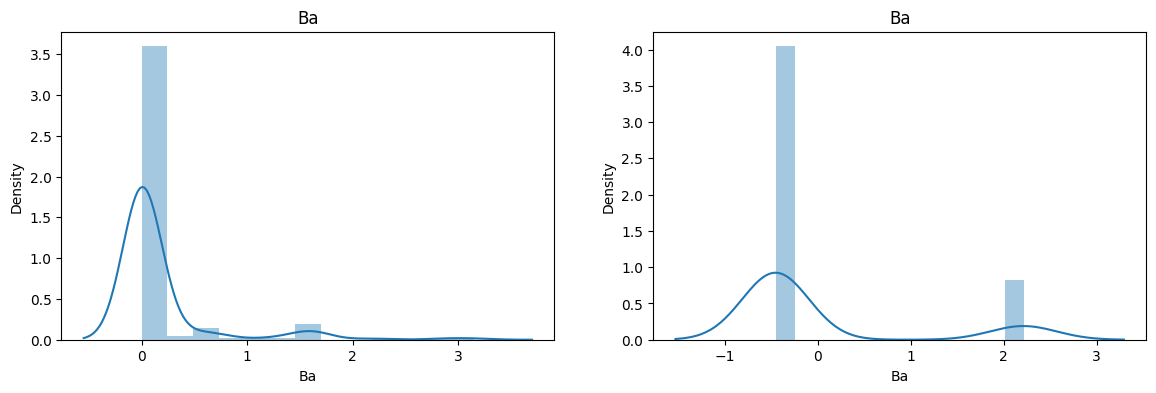

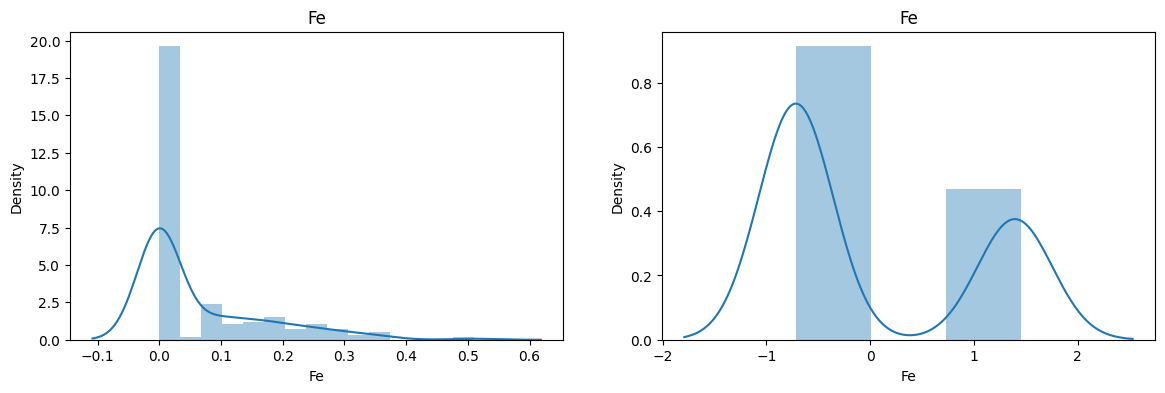

In [20]:

# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(X_train_transformed[col])
    plt.title(col)

    plt.show()

In [21]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.7956189295308949


,cols,Yeo_Johnson_lambdas
0,RI,-31.838081
1,Na,1.170025
2,Mg,2.530420
3,Al,-0.000375
4,Si,16.373046
5,K,-0.828452
6,Ca,-1.242997
7,Ba,-8.588139
8,Fe,-13.493488


In [22]:
# applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LogisticRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

np.float64(0.6443066977316774)

In [23]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)

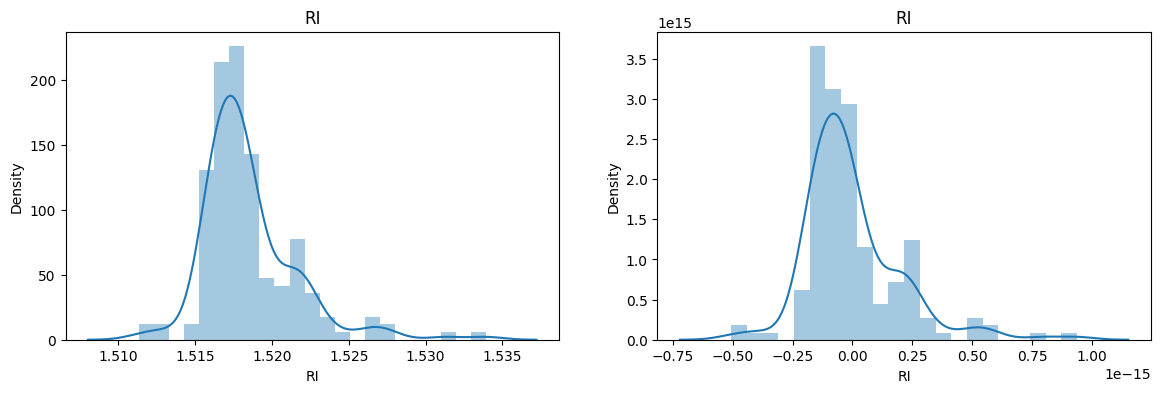

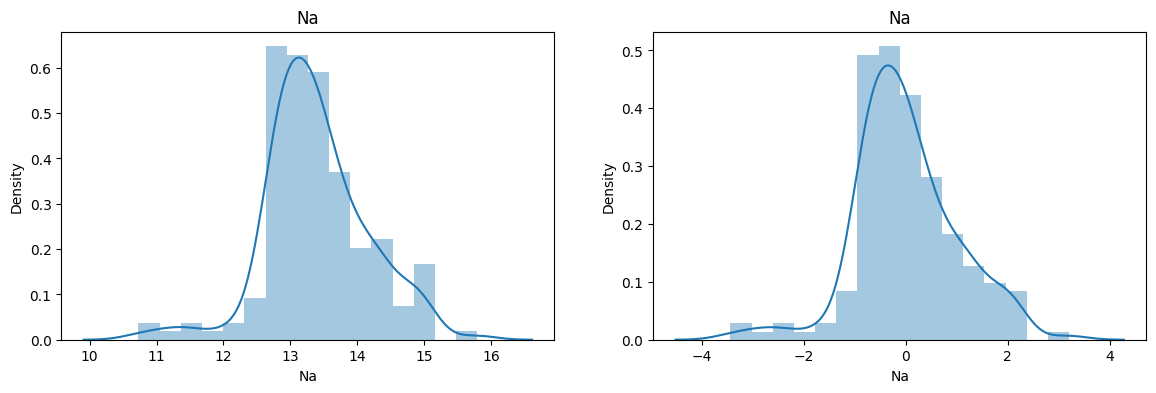

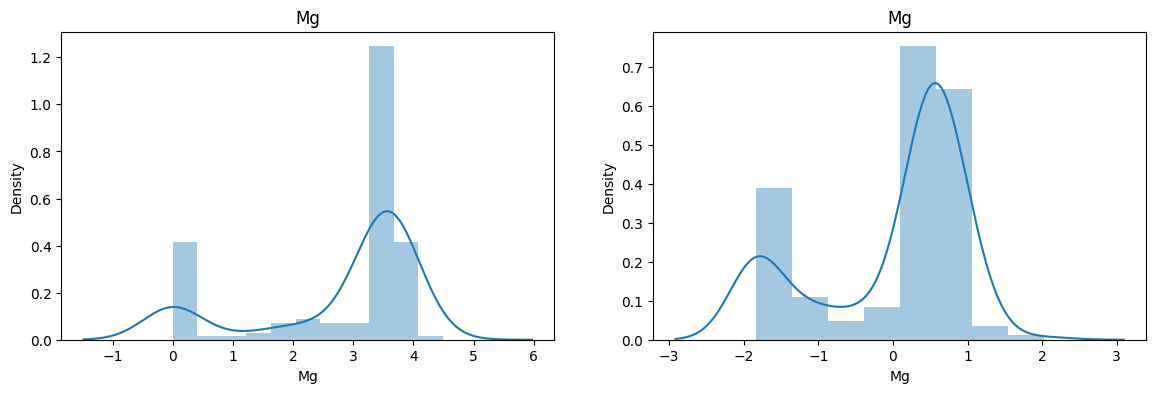

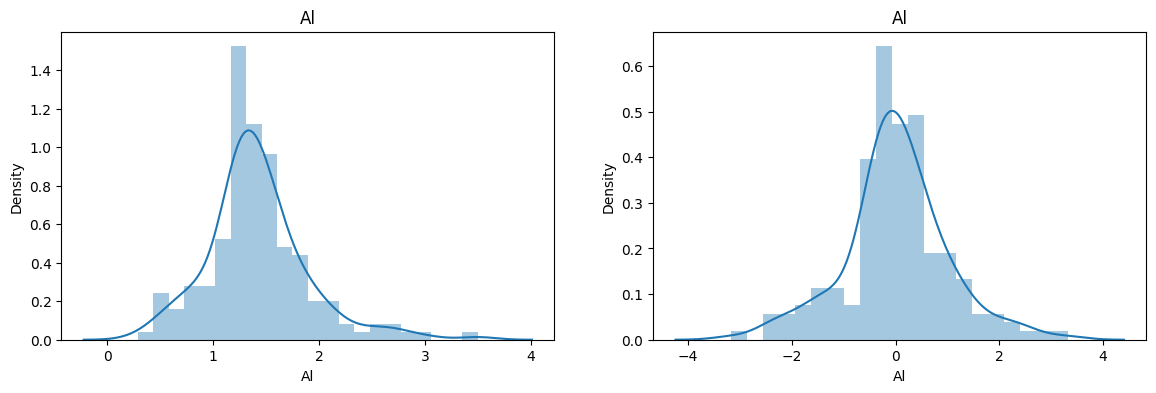

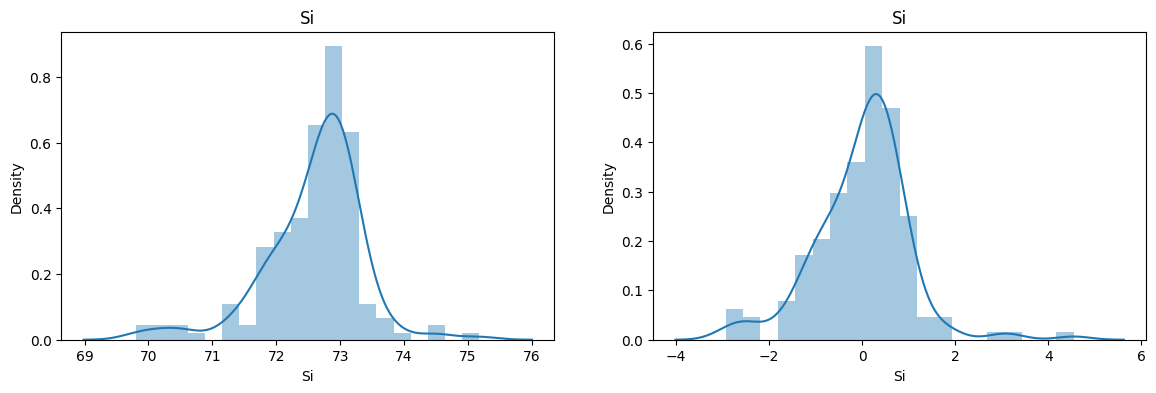

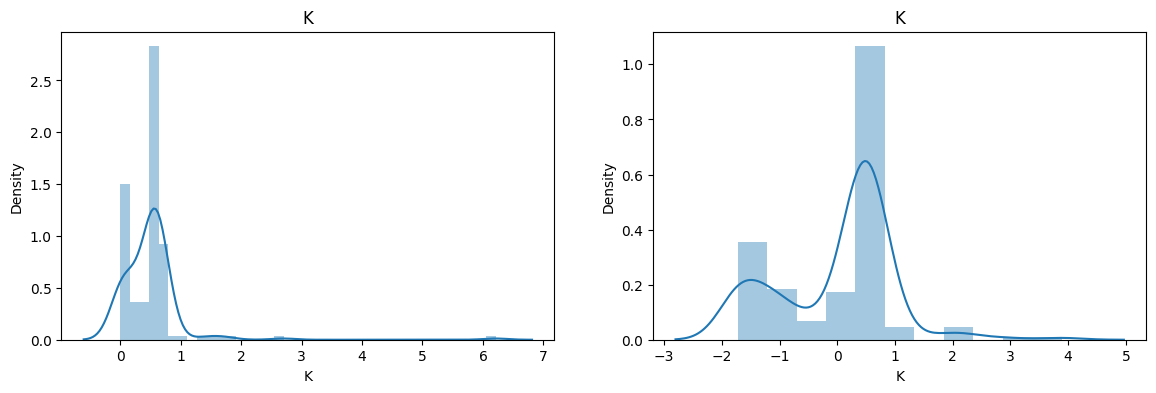

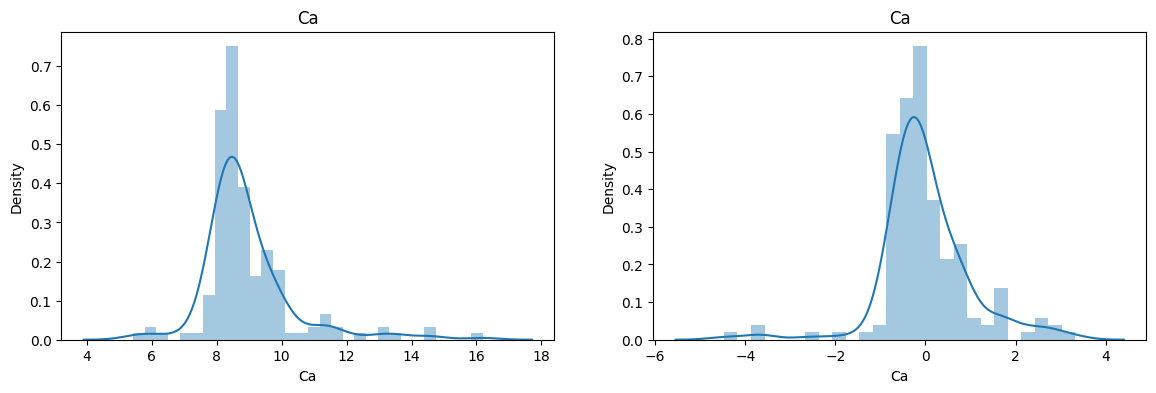

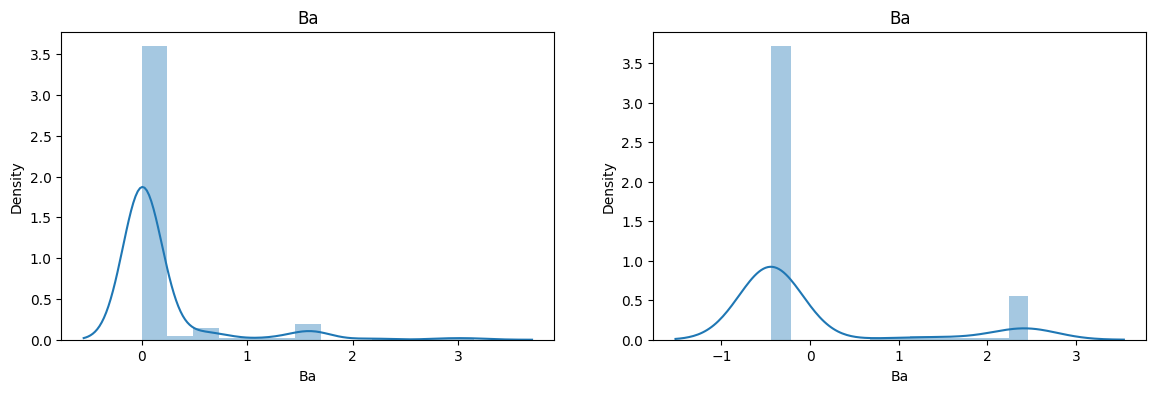

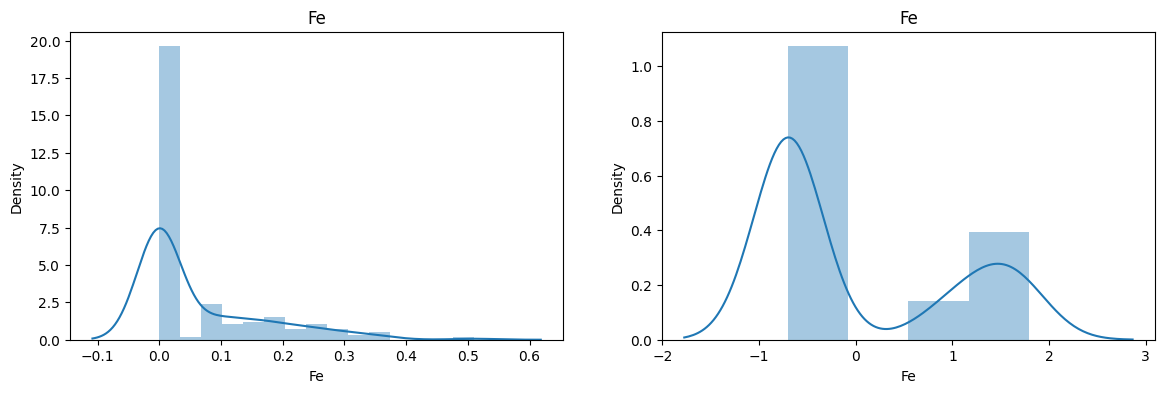

In [24]:
# Before and after comparision for Yeo-Johnson

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(X_train_transformed2[col])
    plt.title(col)

    plt.show()

In [25]:
# Side by side Lambdas
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,RI,-32.809115,-31.838081
1,Na,-0.186886,1.170025
2,Mg,2.236725,2.530420
3,Al,0.003156,-0.000375
4,Si,12.624121,16.373046
5,K,-0.983783,-0.828452
6,Ca,-1.357418,-1.242997
7,Ba,-8.377087,-8.588139
8,Fe,-14.695509,-13.493488
